scatter plots - ggplot

In [25]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load rater data
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
]

raters_data = [pd.read_csv(file) for file in raters_files]

# Define metrics
metrics = {
    'Rating': lambda df: np.mean([df['rating1'].to_numpy(), df['rating2'].to_numpy()], axis=0),
    'Rating 1': lambda df: df['rating1'].to_numpy(),
    'Rating 2': lambda df: df['rating2'].to_numpy(),
    'Blur': lambda df: df['blur'].to_numpy(),
    'Noise': lambda df: df['noise'].to_numpy(),
    'Motion': lambda df: df['motion'].to_numpy(),
    'BgAir': lambda df: df['bgair'].to_numpy(),
    'Eyes Closed': lambda df: np.where(df['artifacts'].to_numpy() == "['eyes-open']", 1, 0),
}

# Function to create interactive scatter plots
def plot_metric_interactive(metric_name, metric_funcs, raters_data):
    all_data = []
    
    for rater_index, df in enumerate(raters_data):
        metric_data = metric_funcs[metric_name](df)
        subjects = np.arange(len(metric_data))
        
        temp_df = pd.DataFrame({
            'Subject Index': subjects,
            metric_name: metric_data,
            'Rater': f'Rater {rater_index + 1}'
        })
        
        all_data.append(temp_df)
    
    merged_data = pd.concat(all_data, ignore_index=True)
    
    fig = px.scatter(
        merged_data, 
        x='Subject Index', 
        y=metric_name, 
        color='Rater', 
        hover_data={'Subject Index': True, metric_name: True, 'Rater': True},
        title=f"{metric_name} Comparison Across Raters",
        template="plotly_white"
    )
    
    fig.show()

# Generate interactive plots for all metrics
for metric_name in metrics.keys():
    plot_metric_interactive(metric_name, metrics, raters_data)


pie charts

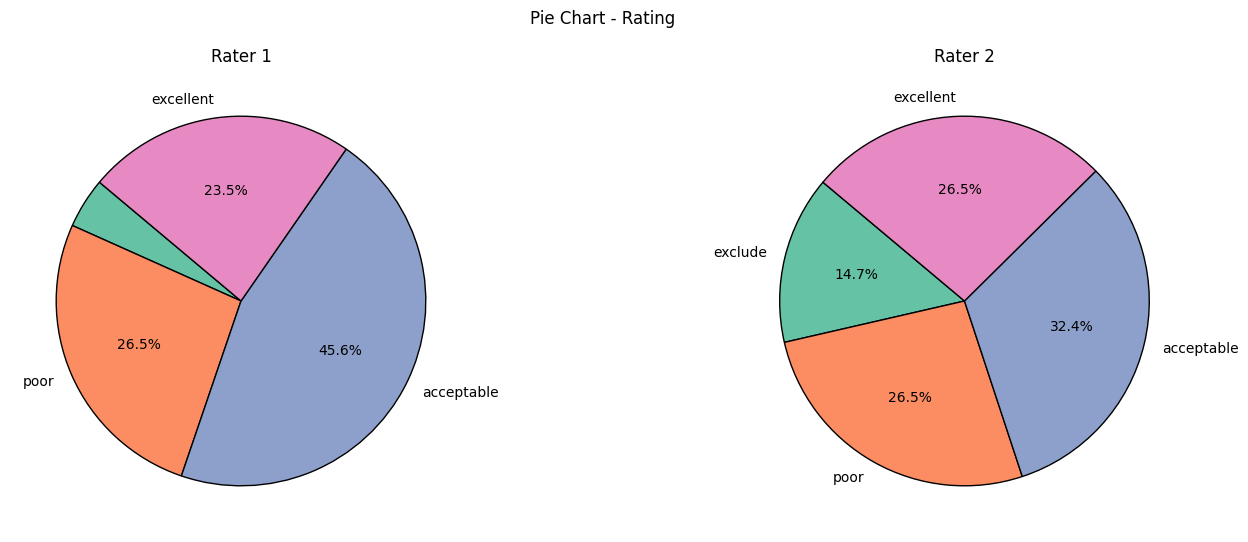

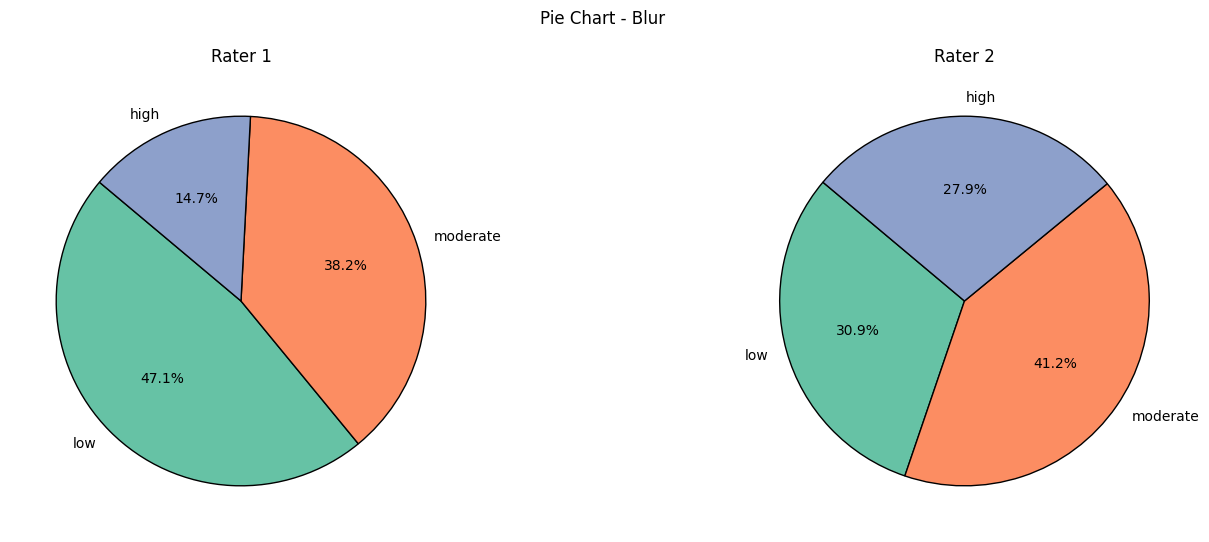

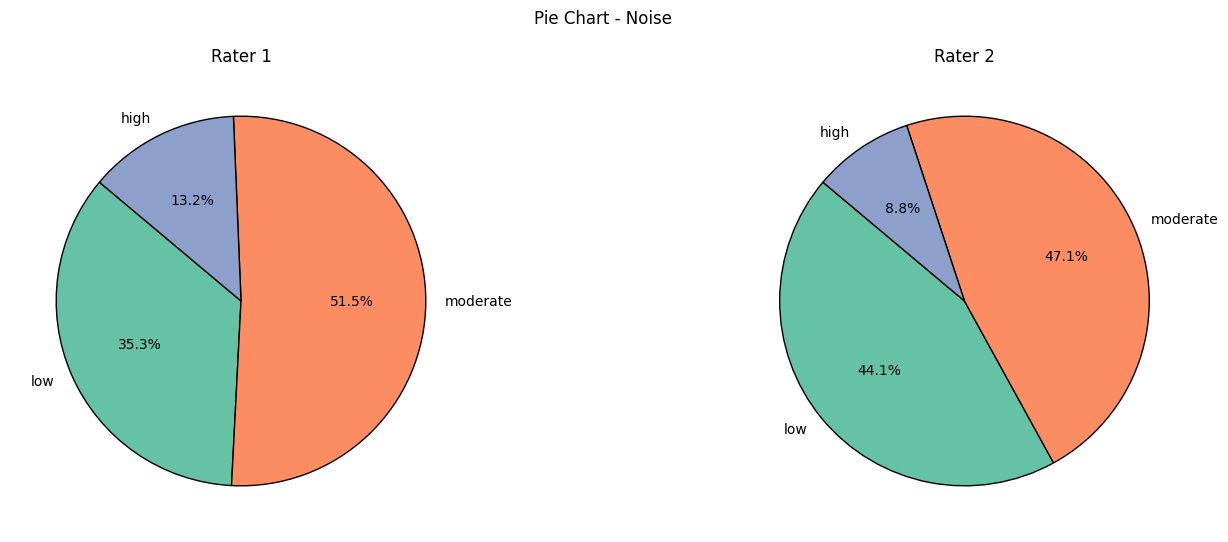

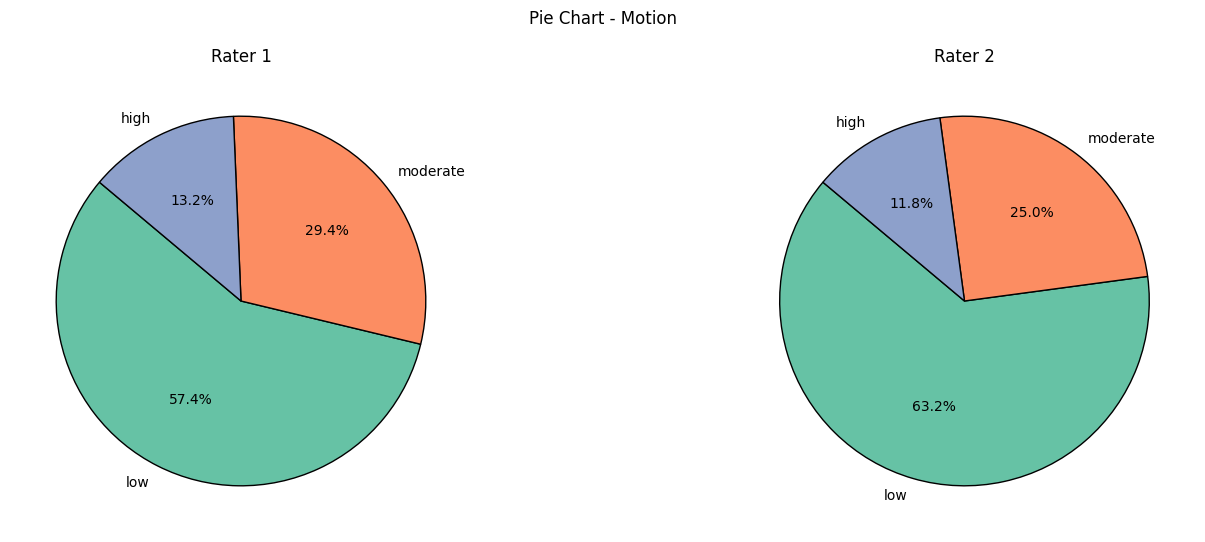

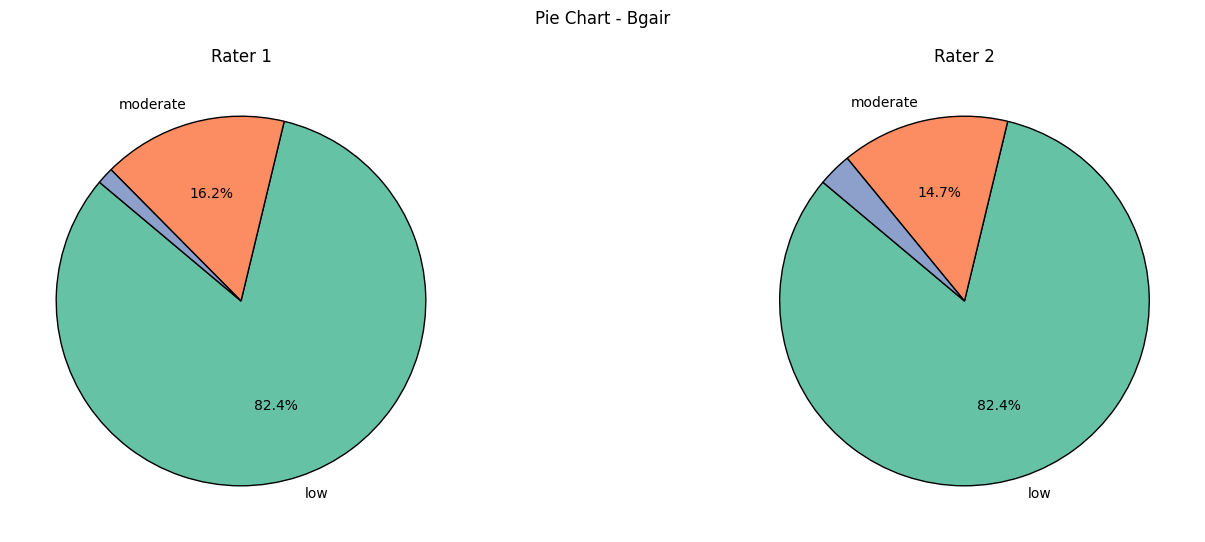

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Raters' data files
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv'
]

# Define metrics and categories
metrics = {
    'rating_text': ['exclude', 'poor', 'acceptable', 'excellent'],
    'blur_text': ['low', 'moderate', 'high'],
    'noise_text': ['low', 'moderate', 'high'],
    'motion_text': ['low', 'moderate', 'high'],
    'bgair_text': ['low', 'moderate', 'high']
}

# Colors for 4 and 3 categories (more homogeneous palette)
colors_map = {
    4: ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'],
    3: ['#66c2a5', '#fc8d62', '#8da0cb']
}

# Threshold below which labels are not displayed
LABEL_THRESHOLD = 5  # Percent

# Load data
raters_data = [pd.read_csv(file) for file in raters_files]

# Generate pie charts for each metric
for metric_name, categories in metrics.items():
    num_categories = len(categories)
    colors = colors_map[num_categories]

    fig, axes = plt.subplots(1, len(raters_data), figsize=(8 * len(raters_data), 6))
    
    if len(raters_data) == 1:  # Handle single subplot case
        axes = [axes]

    for i, (rater_data, ax) in enumerate(zip(raters_data, axes)):
        counts = [rater_data[metric_name].to_list().count(cat) for cat in categories]
        total = sum(counts)
        percentages = [(count / total) * 100 for count in counts] if total > 0 else [0] * len(counts)
        
        # Filter labels below threshold
        filtered_labels = [
            f"{categories[idx]}" if percentages[idx] >= LABEL_THRESHOLD else ""
            for idx in range(len(categories))
        ]
        
        ax.pie(
            counts,
            labels=filtered_labels,
            autopct=lambda p: f'{p:.1f}%' if p >= LABEL_THRESHOLD else '',  # Hide small slices
            startangle=140,
            colors=colors,
            wedgeprops={'edgecolor': 'black'}  # Add edge color for better visibility
        )
        ax.set_title(f'Rater {i + 1}')
        ax.set_aspect('equal')  # Ensures equal aspect ratio for all subplots
    
    # Adjust layout manually to prevent size mismatch
    fig.subplots_adjust(left=0.1, right=0.9, wspace=0.3)
    fig.suptitle(f'Pie Chart - {metric_name.replace("_text", "").capitalize()}')
    fig.set_facecolor('white')
    
    plt.show()


ICC(A,1) + Cohen's Kappa (for 2 raters)

* ICC(A,1) is sensitive to individual rater differences and can be misleading when many 0s dominate

* Cohen's Kappa measures the agreement on binary sets

In [27]:
import pandas as pd
import numpy as np
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

# Read ratings.csv for all raters
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
    # Add paths for other rater files as needed
]

# Load data for all raters
raters_data = [pd.read_csv(file) for file in raters_files]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine data into a long-format DataFrame for ICC computation
def prepare_icc_data(metric_name):
    data = []
    for rater_idx, rater in enumerate(raters_data):
        for subject_idx, value in enumerate(rater[metric_name].to_numpy()):
            data.append([subject_idx, rater_idx, value])
    return pd.DataFrame(data, columns=['subject', 'rater', 'rating'])

# Compute ICC(A,1) and Cohen's Kappa for numeric metrics
for metric_name in metrics_names:
    # ICC(A,1)
    df_icc = prepare_icc_data(metric_name)
    icc_results = pg.intraclass_corr(data=df_icc, targets='subject', raters='rater', ratings='rating')
    icc_a1_row = icc_results.set_index("Type").loc["ICC2"]  # ICC(A,1) corresponds to ICC2 in pingouin
    icc_a1 = icc_a1_row["ICC"]
    ci_low, ci_high = icc_a1_row["CI95%"]  # Extract confidence interval tuple
    print(f"\nMetric: {metric_name} - ICC(A,1): {icc_a1:.3f} [{ci_low:.3f}, {ci_high:.3f}] CI95%")
    
    # Cohen's Kappa
    binary_data = [np.where(rater[metric_name].to_numpy() > 0, 1, 0) for rater in raters_data] # Convert each rater's ratings to binary (0 = absent, 1+ = present)
    for i in range(len(binary_data)):
        for j in range(i + 1, len(binary_data)):
            kappa = cohen_kappa_score(binary_data[i], binary_data[j])
            if np.isnan(kappa):
                print(f"Metric: {metric_name} - Cohen's Kappa Rater {i+1} vs Rater {j+1}: all non-zero ratings (NaN)")
            else:
                print(f"Metric: {metric_name} - Cohen's Kappa Rater {i+1} vs Rater {j+1}: {kappa:.3f}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = sum(
    all(values[0] == v for v in values) for values in zip(*eyes_open_data)
)

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")



Metric: rating - ICC(A,1): 0.772 [0.650, 0.850] CI95%
Metric: rating - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: rating1 - ICC(A,1): 0.782 [0.670, 0.860] CI95%
Metric: rating1 - Cohen's Kappa Rater 1 vs Rater 2: 0.000

Metric: rating2 - ICC(A,1): 0.690 [0.520, 0.800] CI95%
Metric: rating2 - Cohen's Kappa Rater 1 vs Rater 2: all non-zero ratings (NaN)

Metric: blur - ICC(A,1): 0.284 [0.060, 0.480] CI95%
Metric: blur - Cohen's Kappa Rater 1 vs Rater 2: 0.050

Metric: noise - ICC(A,1): 0.427 [0.210, 0.600] CI95%
Metric: noise - Cohen's Kappa Rater 1 vs Rater 2: 0.078

Metric: motion - ICC(A,1): 0.424 [0.210, 0.600] CI95%
Metric: motion - Cohen's Kappa Rater 1 vs Rater 2: 0.274

Metric: bgair - ICC(A,1): 0.199 [-0.040, 0.420] CI95%
Metric: bgair - Cohen's Kappa Rater 1 vs Rater 2: 0.149

Eyes open agreement: 86.76% of cases


/home/jaimebarranco/miniconda3/envs/fetal_brain_qc/lib/python3.9/site-packages/sklearn/metrics/_classification.py:673: RuntimeWarning:

invalid value encountered in scalar divide

/home/jaimebarranco/miniconda3/envs/fetal_brain_qc/lib/python3.9/site-packages/sklearn/metrics/_classification.py:673: RuntimeWarning:

invalid value encountered in scalar divide



ICC(A,k) + Fleiss' Kappa (for >2 raters)

* ICC(A,k) accounts for multiple raters and gives a more stable estimate of agreement

* Fleiss' Kappa replaces Cohen's for multi-rater agreement

In [28]:
import pandas as pd
import numpy as np
import pingouin as pg
from statsmodels.stats.inter_rater import fleiss_kappa

# Read ratings.csv for all raters
raters_files = [
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/jaime/ratings.csv',
    '/mnt/sda1/Repos/a-eye/Output/mri_qc/fetal/eye_qc_83/2_ratings/2_remaining_68/bene/ratings.csv',
    # Add paths for other rater files as needed
]

# Load data for all raters
raters_data = [pd.read_csv(file) for file in raters_files]

# Metrics names
metrics_names = ['rating', 'rating1', 'rating2', 'blur', 'noise', 'motion', 'bgair']

# Combine data into a long-format DataFrame for ICC computation
def prepare_icc_data(metric_name):
    data = []
    for rater_idx, rater in enumerate(raters_data):
        for subject_idx, value in enumerate(rater[metric_name].to_numpy()):
            data.append([subject_idx, rater_idx, value])
    return pd.DataFrame(data, columns=['subject', 'rater', 'rating'])

# Compute ICC(A,k) and Fleiss' Kappa for numeric metrics
for metric_name in metrics_names:
    # ICC(A,k)
    df_icc = prepare_icc_data(metric_name)
    icc_results = pg.intraclass_corr(data=df_icc, targets='subject', raters='rater', ratings='rating')
    icc_a1_row = icc_results.set_index("Type").loc["ICC2k"]  # Use ICC(A,k) instead of ICC(A,1)
    icc_a1 = icc_a1_row["ICC"]
    ci_low, ci_high = icc_a1_row["CI95%"]
    print(f"\nMetric: {metric_name} - ICC(A,k): {icc_a1:.3f} [{ci_low:.3f}, {ci_high:.3f}] CI95%")

    # Convert ratings to binary (0 = absent, 1+ = present)
    binary_data = [np.where(rater[metric_name].to_numpy() > 0, 1, 0) for rater in raters_data]

    # Construct contingency table for Fleiss' Kappa
    num_subjects = len(binary_data[0])  # Number of items rated
    num_raters = len(binary_data)       # Number of raters
    category_counts = np.zeros((num_subjects, 2))  # Two categories: 0 (absent), 1 (present)

    for subject_idx in range(num_subjects):
        for rater_idx in range(num_raters):
            category_counts[subject_idx, binary_data[rater_idx][subject_idx]] += 1

    # Compute Fleiss' Kappa
    kappa_fleiss = fleiss_kappa(category_counts)
    print(f"Metric: {metric_name} - Fleiss' Kappa: {kappa_fleiss:.3f}")

# Compute agreement for "eyes_open" (categorical metric)
eyes_open_data = [np.where(rater['artifacts'].to_numpy() == "['eyes-open']", 1, 0) for rater in raters_data]
total_cases = len(eyes_open_data[0])

agreement_count = sum(
    all(values[0] == v for v in values) for values in zip(*eyes_open_data)
)

print(f"\nEyes open agreement: {np.round(agreement_count / total_cases * 100, 2)}% of cases")



Metric: rating - ICC(A,k): 0.871 [0.790, 0.920] CI95%
Metric: rating - Fleiss' Kappa: nan

Metric: rating1 - ICC(A,k): 0.878 [0.800, 0.920] CI95%
Metric: rating1 - Fleiss' Kappa: -0.007

Metric: rating2 - ICC(A,k): 0.817 [0.690, 0.890] CI95%
Metric: rating2 - Fleiss' Kappa: nan

Metric: blur - ICC(A,k): 0.442 [0.110, 0.650] CI95%
Metric: blur - Fleiss' Kappa: -0.026

Metric: noise - ICC(A,k): 0.599 [0.350, 0.750] CI95%
Metric: noise - Fleiss' Kappa: 0.008

Metric: motion - ICC(A,k): 0.595 [0.340, 0.750] CI95%
Metric: motion - Fleiss' Kappa: 0.237

Metric: bgair - ICC(A,k): 0.332 [-0.090, 0.590] CI95%
Metric: bgair - Fleiss' Kappa: 0.146

Eyes open agreement: 86.76% of cases


/home/jaimebarranco/miniconda3/envs/fetal_brain_qc/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

/home/jaimebarranco/miniconda3/envs/fetal_brain_qc/lib/python3.9/site-packages/statsmodels/stats/inter_rater.py:266: RuntimeWarning:

invalid value encountered in scalar divide

